In [8]:
!pip install opencv-python
!pip install pytesseract
# Para linux
# !apt-get install tesseract-ocr
# !apt-get tesseract-ocr-por
# !apt-get libtesseract-dev


## para o Windows https://tesseract-ocr.github.io/tessdoc/Downloads.html
## e setar o caminho do tesseract no código



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pytesseract


# Diga ao Python exatamente onde o executável foi instalado
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

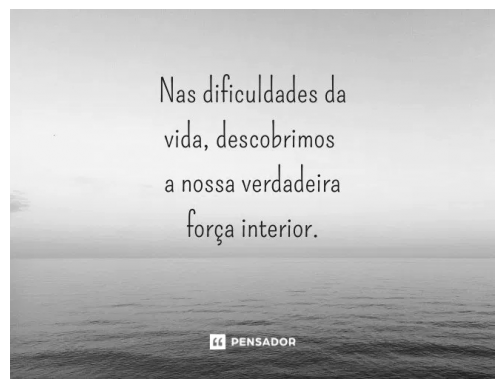

In [10]:
import cv2

imagem = cv2.imread('pensador.webp')

# Converter a imagem para escala de cinza para facilitar a extração de texto
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

import matplotlib.pyplot as plt

plt.imshow(imagem_cinza, cmap='gray')
plt.axis('off') # Ocultar os eixos
plt.show()



In [11]:
# Precisei instalar o idioma português para o Tesseract reconhecer o texto em português. O idioma padrão é o inglês, e por isso ele não reconhecia as palavras em português.

# 1. Baixe o "cérebro" em Português
# Você precisa do arquivo de treinamento do idioma português:

# Acesse este link oficial: por.traineddata (GitHub).

# Clique no ícone de Download (o botão "Download raw file").
print("--- Testando com idioma padrão (English) ---")
texto_en = pytesseract.image_to_string('pensador.webp')
print("Sucesso no teste inglês!")
print(texto_en[:100]) # Printa só o começo

    # 2. Listar idiomas instalados
print("\n--- Idiomas que o seu Tesseract conhece ---")
print(pytesseract.get_languages(config=''))


--- Testando com idioma padrão (English) ---
Sucesso no teste inglês!
Nas dificuldades da

vida, descobrimos

a nossa verdadeira

forga interior.



--- Idiomas que o seu Tesseract conhece ---
['eng', 'osd', 'por']


In [30]:
texto = pytesseract.image_to_string(imagem_cinza)
print("Texto extraído da imagem:")
print(texto)

Texto extraído da imagem:
Nas dificuldades da

vida, descobrimos
a nossa verdadeira

forga interior.

Gi Pensavor




In [31]:
# Aplicando técnicas de pré-processamento para melhorar a extração de texto
_, imagem_binarizada = cv2.threshold(imagem_cinza, 142, 255, cv2.THRESH_BINARY)

# Extraindo texto da imagem binarizada
texto_binarizado = pytesseract.image_to_string(imagem_binarizada)
print("Texto extraído da imagem binarizada:")
print(texto_binarizado)

Texto extraído da imagem binarizada:
Nas dificuldades da

vida, descobrimos

a nossa verdadeira

forga interior.




In [32]:
#Aplicando métode de Otsu para binarização automática
_, imagem_otsu = cv2.threshold(imagem_cinza, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
texto_otsu = pytesseract.image_to_string(imagem_otsu)
print("Texto extraído da imagem usando Otsu:")
print(texto_otsu)

Texto extraído da imagem usando Otsu:
Nas dificuldades da

vida, descobrimos
a nossa verdadeira

forga interior.

Ei eensapor




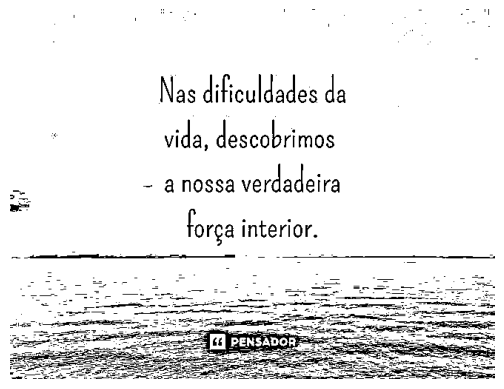

Texto extraído da imagem usando limiarização adaptativa:
Nas dificuldades da
vida, descobrimos
~ anossa verdadeira

forga interior.




In [33]:
#Aplicando limiarização adaptativa
imagem_adaptativa = cv2.adaptiveThreshold(imagem_cinza, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 5)

plt.imshow(imagem_adaptativa, cmap='gray')
plt.axis('off') # Ocultar os eixos
plt.show()

texto_adaptativo = pytesseract.image_to_string(imagem_adaptativa)
print("Texto extraído da imagem usando limiarização adaptativa:")
print(texto_adaptativo)

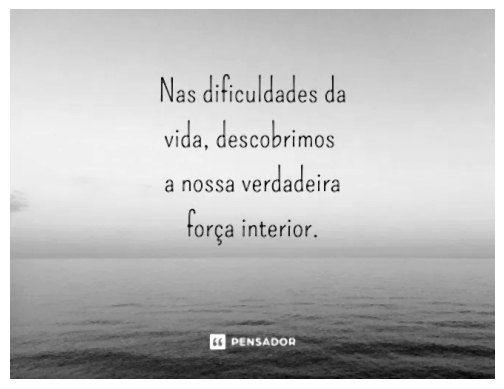

Texto extraído da imagem usando filtro de mediana:
Nas dificuldades da

vida, descobrimos
a nossa verdadeira

forga interior.

@ pensavon




In [34]:
# Aplicando filtro de mediana para reduzir ruído
imagem_median = cv2.medianBlur(imagem_cinza, 3)

plt.imshow(imagem_median, cmap='gray')
plt.axis('off') # Ocultar os eixos
plt.show()
texto_median = pytesseract.image_to_string(imagem_median)
print("Texto extraído da imagem usando filtro de mediana:") 
print(texto_median)

In [35]:
from difflib import SequenceMatcher
# Analise da extração
texto_original = """
Nas dificuldades da vida,
descobrimos a nossa verdadeira força interior.
" Pensador
"""

# Variaveis que contem os textos OCR a serem comparados
textos_ocr = {
    "Texto Extraído": texto,
    "Texto Binarizado": texto_binarizado,
    "Texto Otsu": texto_otsu,
    "Texto Adaptativo": texto_adaptativo,
    "Texto Filtro de Mediana": texto_median
}

def compare_texts(texto_original, texto_ocr):
    matcher = SequenceMatcher(None, texto_original, texto_ocr)
    match_ratio = matcher.ratio()
    return match_ratio

def main():
    original_len = len(texto_original)
    print(f"Texto Original: {original_len} caracteres\n")
    for variant_name, texto_ocr in textos_ocr.items():
        ocr_len = len(texto_ocr)
        accuracy = compare_texts(texto_original, texto_ocr)
        accuracy_percentage = accuracy * 100
        print(f"Resultado para {variant_name}:")
        print(f"Quantidade de caracteres extraídos: {ocr_len}")
        print(f"Precisão em relação ao texto original: {accuracy_percentage:.2f}%\n")

if __name__ == "__main__":
    main()


Texto Original: 85 caracteres

Resultado para Texto Extraído:
Quantidade de caracteres extraídos: 89
Precisão em relação ao texto original: 88.51%

Resultado para Texto Binarizado:
Quantidade de caracteres extraídos: 77
Precisão em relação ao texto original: 85.19%

Resultado para Texto Otsu:
Quantidade de caracteres extraídos: 89
Precisão em relação ao texto original: 87.36%

Resultado para Texto Adaptativo:
Quantidade de caracteres extraídos: 76
Precisão em relação ao texto original: 85.71%

Resultado para Texto Filtro de Mediana:
Quantidade de caracteres extraídos: 88
Precisão em relação ao texto original: 86.71%

